# Predikce nájemného - XGBoost

Tento notebook obsahuje implementaci XGBoost modelu pro predikci nájemného bytů v ČR.

**Proč NEPOUŽÍVÁME StandardScaler:**
Stromové modely (XGBoost, LightGBM, CatBoost, Random Forest) nepotřebují škálování, protože:
- Rozhodují se na základě prahových hodnot (split points)
- Nezáleží na absolutní hodnotě features, pouze na jejich pořadí
- Škálování nemění pořadí hodnot → nemá vliv na výsledek

**Obsah:**
1. Předzpracování dat (bez scaleru)
2. XGBoost s RandomizedSearchCV
3. XGBoost s Optuna (Bayesian optimization)
4. SHAP Values - interpretace modelu

## 1. Import knihoven a načtení dat

In [1]:
import pandas as pd
import numpy as np
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

import xgboost as xgb
from xgboost import XGBRegressor
import optuna

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Nastavení random seed pro reprodukovatelnost
np.random.seed(42)

In [2]:
# Načtení dat
data = pd.read_csv('../data/apartment_properties_rent.csv')
print(f'Počet záznamů: {len(data)}')
data.head()

Počet záznamů: 20659


,id,building_type,city,condition,estate_type,floor_space,land_space,price,region,sale_type,source,disposition,equipment,penb
0,845394,UNDEFINED,Mariánské Lázně,UNDEFINED,apartment,20.0,0.0,16340.0,Karlovarský kraj,RENT,bezrealitky,DISP_1_KK,FURNISHED,G
1,600390,PANEL,Brno,VERY_GOOD,apartment,36.0,0.0,9500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_1_KK,PARTIALLY,A
2,843682,BRICK,Brno,VERY_GOOD,apartment,60.0,0.0,20500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_2_1,FURNISHED,G
3,435994,BRICK,Opava,VERY_GOOD,apartment,38.0,0.0,7000.0,Moravskoslezský kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G
4,843695,BRICK,Lipník nad Bečvou,VERY_GOOD,apartment,41.0,0.0,5200.0,Olomoucký kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G


## 2. Předzpracování dat

In [3]:
# Zamíchání dat pro lepší generalizaci
data_shuffled = data.sample(n=len(data), random_state=1)

# Vyplnění chybějících hodnot
data_shuffled.loc[:, 'condition'] = data_shuffled['condition'].fillna('UNDEFINED')
data_shuffled.loc[:, 'land_space'] = data_shuffled['land_space'].fillna(0)
data_shuffled.loc[:, 'disposition'] = data_shuffled['disposition'].fillna('UNDEFINED')
data_shuffled.loc[:, 'equipment'] = data_shuffled['equipment'].fillna('UNDEFINED')
data_shuffled.loc[:, 'penb'] = data_shuffled['penb'].fillna('G')

In [4]:
# Odstranění outlierů
print(f'Počet řádků před odstraněním outlierů: {len(data_shuffled)}')

Q99 = data_shuffled['price'].quantile(0.99)

data_shuffled = data_shuffled[
    (data_shuffled['price'] >= 1000) &
    (data_shuffled['price'] <= Q99) &
    (data_shuffled['floor_space'] >= 10) &
    (data_shuffled['floor_space'] <= 250)
].copy()

print(f'Počet řádků po odstranění outlierů: {len(data_shuffled)}')
print(f'\nStatistiky cen:')
print(f'Průměr: {data_shuffled["price"].mean():.2f} Kč')
print(f'Medián: {data_shuffled["price"].median():.2f} Kč')

Počet řádků před odstraněním outlierů: 20659
Počet řádků po odstranění outlierů: 20172

Statistiky cen:
Průměr: 17687.38 Kč
Medián: 14000.00 Kč


In [5]:
# Odstranění nepotřebných sloupců
data_shuffled.drop(['estate_type', 'sale_type', 'source', 'id'], axis=1, inplace=True)

In [6]:
# Target encoding pro vysokokardinální kategorické proměnné
target_cols = ['city', 'region', 'disposition']
target_encoder = ce.TargetEncoder(cols=target_cols)
data_shuffled[target_cols] = target_encoder.fit_transform(data_shuffled[target_cols], data_shuffled['price'])

In [7]:
# Ordinální kódování pro equipment a penb
equipment_mapping = {'UNDEFINED': 0, 'UNFURNISHED': 1, 'PARTIALLY': 2, 'FURNISHED': 3}
penb_mapping = {'G': 0, 'F': 1, 'E': 2, 'D': 3, 'C': 4, 'B': 5, 'A': 6}

data_shuffled['equipment'] = data_shuffled['equipment'].map(equipment_mapping)
data_shuffled['penb'] = data_shuffled['penb'].map(penb_mapping)

In [8]:
# Odstranění zbývajících NaN hodnot
data_shuffled.dropna(inplace=True)
print(f'Finální počet záznamů: {len(data_shuffled)}')

Finální počet záznamů: 20081


In [9]:
# Rozdělení na features a target
X = data_shuffled.drop('price', axis=1)
y = data_shuffled['price']

## 3. Preprocessing pipeline (BEZ StandardScaler)

Pro XGBoost nepotřebujeme škálování - pouze imputaci a one-hot encoding.

In [10]:
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = ['condition', 'building_type']

# Preprocessor BEZ StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean'))
            # Žádný StandardScaler - XGBoost ho nepotřebuje!
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)
print(f'Shape po preprocessingu: {X_preprocessed.shape}')
print(f'\nPříklad hodnot (první řádek, první 3 features):')
print(f'Bez scaleru: {X_preprocessed[0, :3]}')  # Původní hodnoty, ne standardizované

Shape po preprocessingu: (20081, 32)

Příklad hodnot (první řádek, první 3 features):
Bez scaleru: [25471.47456153    51.             0.        ]


In [11]:
# Získání názvů features pro pozdější použití
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(categorical_feature_names)
print(f'Celkem features: {len(all_feature_names)}')

Celkem features: 32


## 4. Rozdělení dat

In [12]:
# Train/Test split: 80/20
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')

Train size: 16064
Test size: 4017


## 5. XGBoost s RandomizedSearchCV

První přístup - náhodné prohledávání prostoru hyperparametrů.

In [13]:
# Základní model
model = xgb.XGBRegressor(
    n_estimators=10000,
    early_stopping_rounds=20,
    n_jobs=-1,
    random_state=42
)

# Prostor hyperparametrů
param_distributions = {
    "learning_rate": scipy.stats.uniform(loc=0.01, scale=0.2),
    "subsample": scipy.stats.uniform(loc=0.5, scale=0.5),
    "colsample_bytree": scipy.stats.uniform(loc=0.5, scale=0.5),
    "min_child_weight": [1, 3, 5, 7],
    "max_depth": np.arange(3, 10),
    "reg_alpha": [0, 0.1, 1, 5, 10],
    "reg_lambda": [1, 5, 10, 20]
}

In [14]:
# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'\nNejlepší parametry: {random_search.best_params_}')

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Nejlepší parametry: {'colsample_bytree': 0.8317508845540279, 'learning_rate': 0.011012316769243738, 'max_depth': 8, 'min_child_weight': 3, 'reg_alpha': 0.1, 'reg_lambda': 5, 'subsample': 0.7242120714931237}


In [15]:
# Vyhodnocení RandomizedSearchCV modelu
tuned_model = random_search.best_estimator_
y_pred_random = tuned_model.predict(X_test)

print('=== RandomizedSearchCV Výsledky ===')
print(f'MAE: {mean_absolute_error(y_test, y_pred_random):.2f} Kč')
print(f'R²: {r2_score(y_test, y_pred_random):.4f}')

=== RandomizedSearchCV Výsledky ===
MAE: 2755.02 Kč
R²: 0.8534


## 6. XGBoost s Optuna

Druhý přístup - Bayesian optimization pomocí Optuna.
Optuna je efektivnější než RandomizedSearchCV, protože se učí z předchozích pokusů.

In [16]:
def objective(trial):
    """Objective function pro Optuna optimalizaci."""
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'n_estimators': 1000,
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=kfold, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )

    return -np.mean(scores)  # Vrátí pozitivní MAE pro minimalizaci

In [17]:
# Spuštění Optuna optimalizace
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nNejlepší parametry: {study.best_params}')
print(f'Nejlepší MAE (cross-validation): {study.best_value:.2f} Kč')

[I 2026-01-28 16:33:01,430] A new study created in memory with name: no-name-13de0dc3-0f4d-4a38-b794-5036185a8a20


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-28 16:33:04,049] Trial 0 finished with value: 2765.2134466086463 and parameters: {'learning_rate': 0.017945796183225234, 'max_depth': 9, 'reg_alpha': 6.488756904796169, 'reg_lambda': 0.09039324426855752, 'subsample': 0.7207411953508349, 'colsample_bytree': 0.5519988590948256, 'min_child_weight': 2}. Best is trial 0 with value: 2765.2134466086463.
[I 2026-01-28 16:33:06,196] Trial 1 finished with value: 3136.147205936927 and parameters: {'learning_rate': 0.2975975027301742, 'max_depth': 9, 'reg_alpha': 0.08299616148388521, 'reg_lambda': 0.019740512375242, 'subsample': 0.9600605406906952, 'colsample_bytree': 0.561567494434873, 'min_child_weight': 7}. Best is trial 0 with value: 2765.2134466086463.
[I 2026-01-28 16:33:08,602] Trial 2 finished with value: 2808.232344475321 and parameters: {'learning_rate': 0.033207802411495554, 'max_depth': 10, 'reg_alpha': 7.215398658206903, 'reg_lambda': 2.8865299993736007, 'subsample': 0.5260107623093955, 'colsample_bytree': 0.578409422727280

In [18]:
# Trénování finálního modelu s nejlepšími parametry
best_model = XGBRegressor(
    **study.best_params,
    n_estimators=1000,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae'
)

best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-mae:8123.51655	validation_1-mae:7925.12945
[100]	validation_0-mae:3626.60030	validation_1-mae:3791.43232
[200]	validation_0-mae:2527.42482	validation_1-mae:2918.70523
[300]	validation_0-mae:2206.09747	validation_1-mae:2753.21919
[400]	validation_0-mae:2069.16985	validation_1-mae:2720.42938
[500]	validation_0-mae:1995.16738	validation_1-mae:2713.21194
[600]	validation_0-mae:1935.11653	validation_1-mae:2708.44835
[700]	validation_0-mae:1882.51016	validation_1-mae:2703.91965
[800]	validation_0-mae:1833.61049	validation_1-mae:2701.58888
[876]	validation_0-mae:1795.57298	validation_1-mae:2701.89668


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7025602645507795, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='mae', feature_types=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.012385743085638426,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [19]:
# Vyhodnocení Optuna modelu
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print('=== Optuna XGBoost Výsledky ===')
print(f'Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f} Kč')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f} Kč')
print(f'Train R²: {r2_score(y_train, y_pred_train):.4f}')
print(f'Test R²: {r2_score(y_test, y_pred_test):.4f}')

=== Optuna XGBoost Výsledky ===
Train MAE: 1819.94 Kč
Test MAE: 2701.50 Kč
Train R²: 0.9441
Test R²: 0.8506


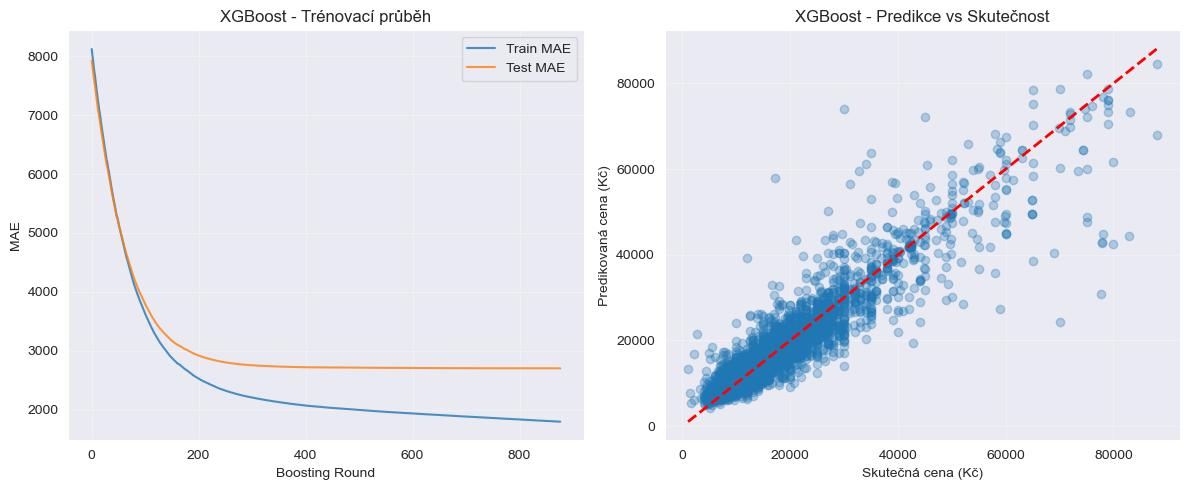

In [20]:
# Vizualizace trénovacího procesu
eval_results = best_model.evals_result()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(eval_results['validation_0']['mae'], label='Train MAE', alpha=0.8)
plt.plot(eval_results['validation_1']['mae'], label='Test MAE', alpha=0.8)
plt.xlabel('Boosting Round')
plt.ylabel('MAE')
plt.title('XGBoost - Trénovací průběh')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Skutečná cena (Kč)')
plt.ylabel('Predikovaná cena (Kč)')
plt.title('XGBoost - Predikce vs Skutečnost')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Vizualizace Optuna optimalizace

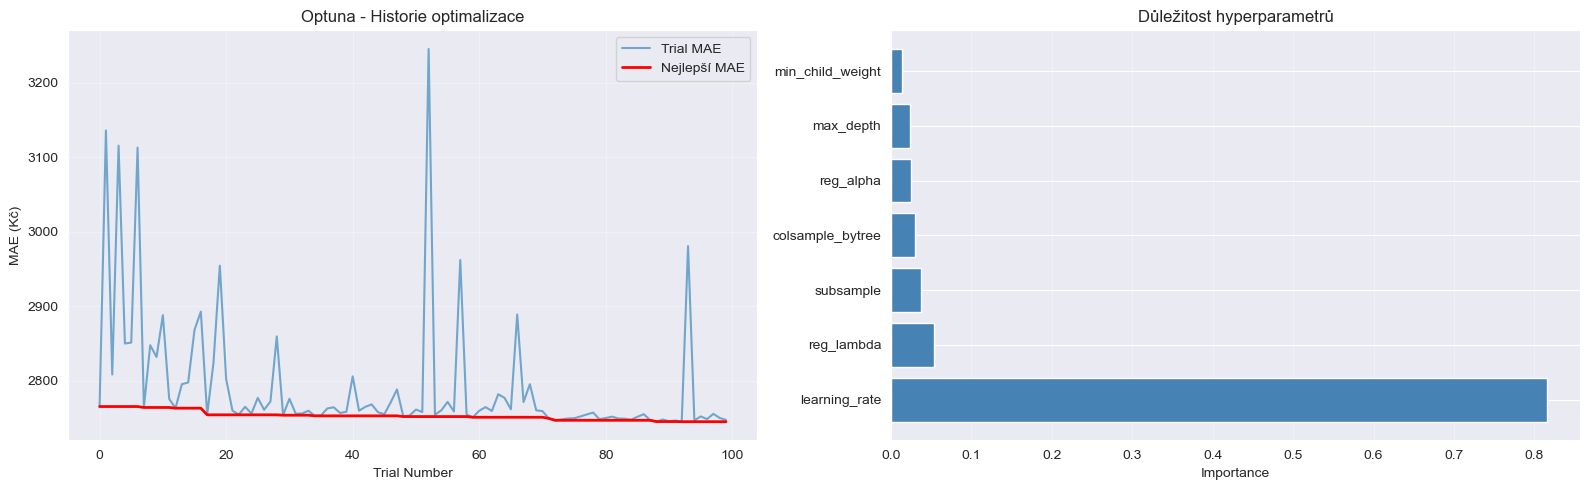

In [21]:
# Historie optimalizace
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.6, label='Trial MAE')
axes[0].plot(trials_df['number'], trials_df['value'].cummin(), color='red', linewidth=2, label='Nejlepší MAE')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('MAE (Kč)')
axes[0].set_title('Optuna - Historie optimalizace')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Důležitost parametrů
param_importance = optuna.importance.get_param_importances(study)
params = list(param_importance.keys())
importances = list(param_importance.values())

axes[1].barh(params, importances, color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Důležitost hyperparametrů')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 8. Feature Importance

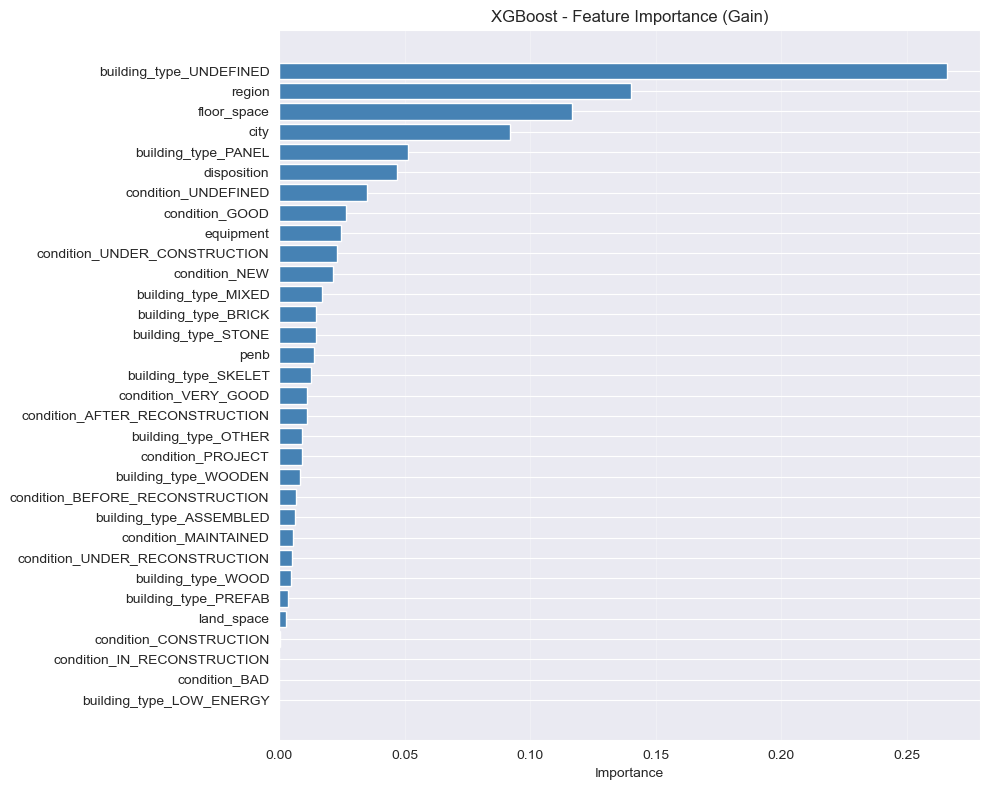

In [22]:
# Feature importance z XGBoost
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost - Feature Importance (Gain)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. SHAP Values - Interpretace modelu (nativní XGBoost)

In [30]:
# Nativní XGBoost SHAP

# Převod dat na DMatrix (interní formát XGBoost)
sample_size = min(1000, len(X_test))
X_sample = X_test[:sample_size]
y_sample = y_test.iloc[:sample_size]

dmatrix_sample = xgb.DMatrix(X_sample)

# Výpočet SHAP hodnot pomocí pred_contribs=True

shap_values_raw = best_model.get_booster().predict(dmatrix_sample, pred_contribs=True)

# Rozdělení na SHAP hodnoty a base value
shap_values = shap_values_raw[:, :-1]  # Všechny sloupce kromě posledního
base_value = shap_values_raw[0, -1]    # Base value (průměrná predikce)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Počet vzorků: {sample_size}')
print(f'Expected value (baseline): {base_value:.2f} Kč')
print(f'\nVerifikace: predikce = base_value + sum(SHAP)')
print(f'Predikce prvního vzorku: {best_model.predict(X_sample[:1])[0]:.2f} Kč')
print(f'Rekonstrukce z SHAP: {base_value + shap_values[0].sum():.2f} Kč')

SHAP values shape: (1000, 32)
Počet vzorků: 1000
Expected value (baseline): 17731.44 Kč

Verifikace: predikce = base_value + sum(SHAP)
Predikce prvního vzorku: 18079.60 Kč
Rekonstrukce z SHAP: 18083.66 Kč


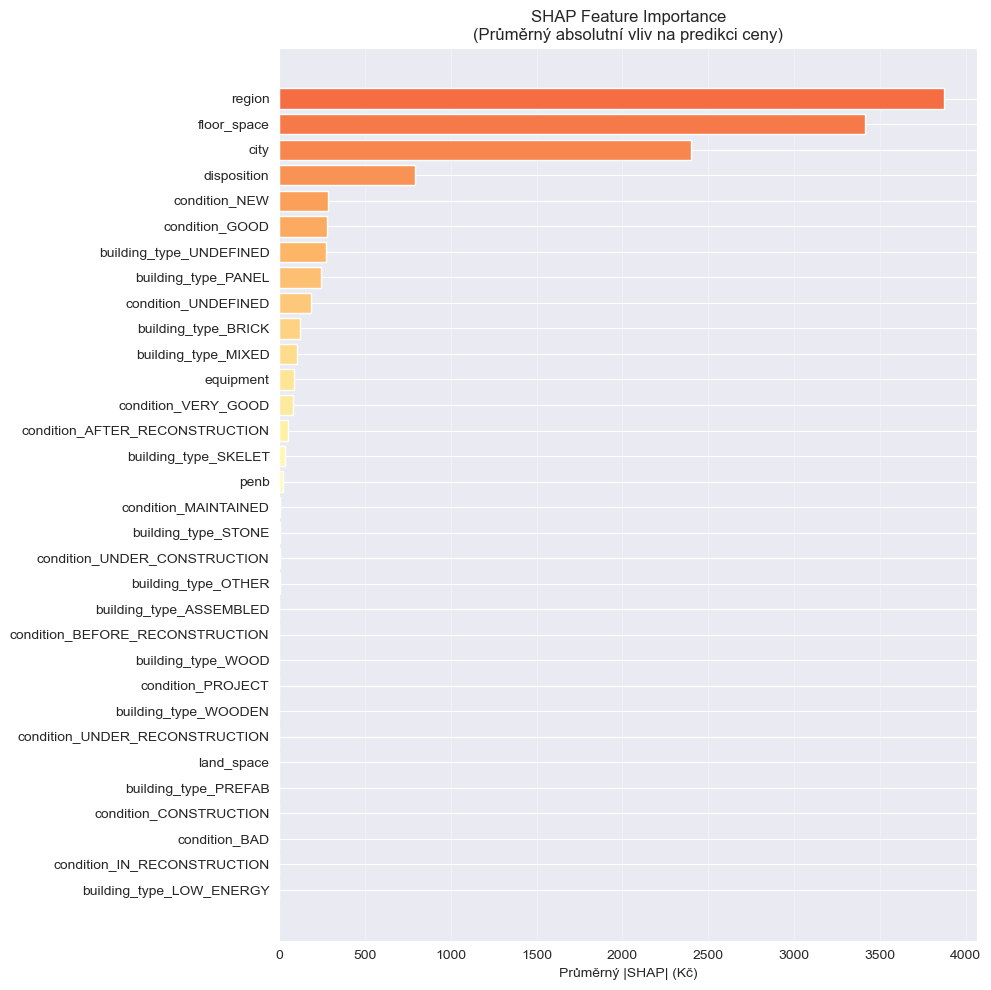


Top 5 nejdůležitějších features:
  region: 3872.19 Kč
  floor_space: 3414.69 Kč
  city: 2400.07 Kč
  disposition: 790.93 Kč
  condition_NEW: 286.00 Kč


In [31]:

# Výpočet průměrné absolutní SHAP hodnoty pro každou feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Vytvoření DataFrame pro vizualizaci
shap_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

# Vizualizace
plt.figure(figsize=(10, 10))
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(shap_importance_df)))
plt.barh(shap_importance_df['feature'], shap_importance_df['mean_abs_shap'], color=colors)
plt.xlabel('Průměrný |SHAP| (Kč)')
plt.title('SHAP Feature Importance\n(Průměrný absolutní vliv na predikci ceny)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Top 5 features
print('\nTop 5 nejdůležitějších features:')
for i, row in shap_importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['mean_abs_shap']:.2f} Kč")

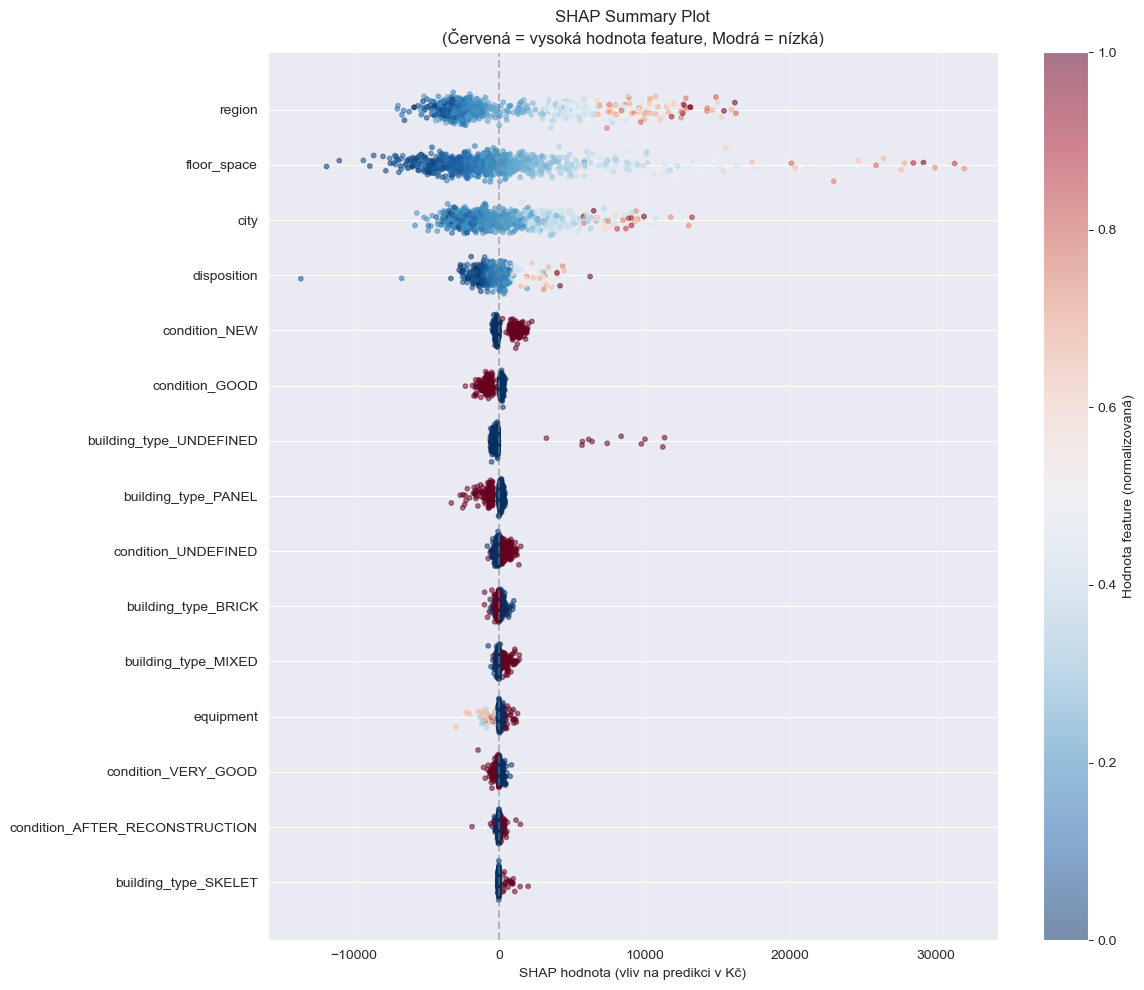

In [32]:
# Seřazení features podle důležitosti
sorted_idx = np.argsort(mean_abs_shap)
top_n = 15  # Max 15 features

fig, ax = plt.subplots(figsize=(12, 10))

for i, idx in enumerate(sorted_idx[-top_n:]):
    feature_shap = shap_values[:, idx]
    feature_values = X_sample[:, idx]
    
    # Normalizace hodnot features pro barvu (0-1)
    fv_min, fv_max = feature_values.min(), feature_values.max()
    if fv_max > fv_min:
        feature_norm = (feature_values - fv_min) / (fv_max - fv_min)
    else:
        feature_norm = np.zeros_like(feature_values)
    
    # Přidání jitteru pro lepší vizualizaci
    y_jitter = np.random.normal(0, 0.1, size=len(feature_shap))
    
    # Scatter plot s barvou podle hodnoty feature
    scatter = ax.scatter(
        feature_shap, 
        np.full_like(feature_shap, i) + y_jitter,
        c=feature_norm,
        cmap='RdBu_r',
        alpha=0.5,
        s=10
    )

ax.set_yticks(range(top_n))
ax.set_yticklabels([all_feature_names[idx] for idx in sorted_idx[-top_n:]])
ax.set_xlabel('SHAP hodnota (vliv na predikci v Kč)')
ax.set_title('SHAP Summary Plot\n(Červená = vysoká hodnota feature, Modrá = nízká)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hodnota feature (normalizovaná)')

plt.tight_layout()
plt.show()

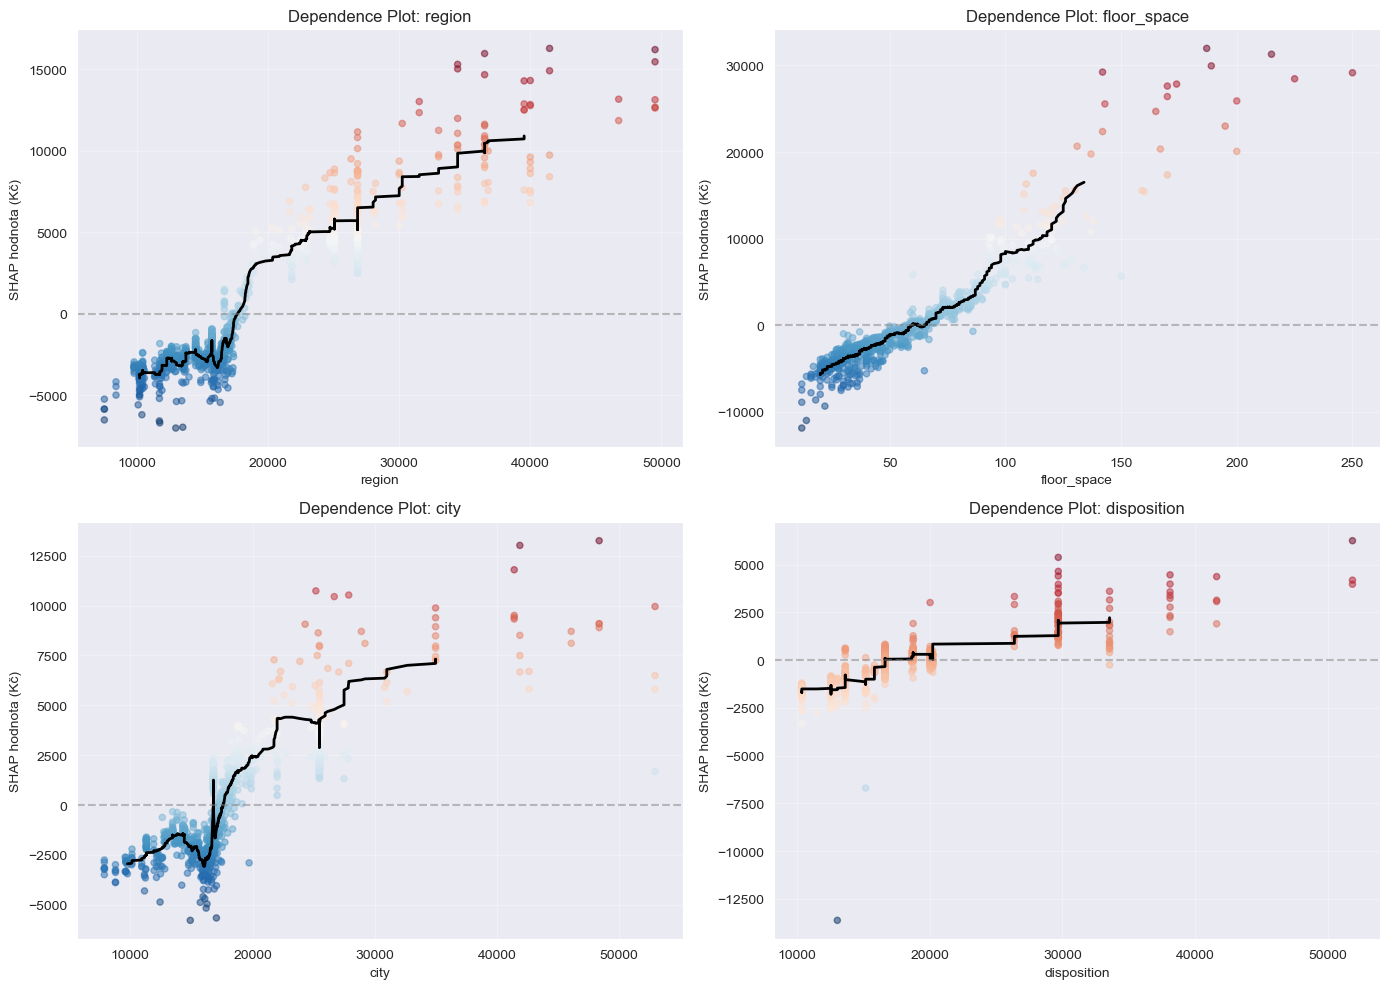

In [33]:
# Top 4 features podle SHAP importance
top_4_idx = np.argsort(mean_abs_shap)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(top_4_idx):
    feature_name = all_feature_names[idx]
    feature_values = X_sample[:, idx]
    feature_shap = shap_values[:, idx]
    
    # Scatter plot
    scatter = axes[i].scatter(
        feature_values, 
        feature_shap, 
        c=feature_shap,
        cmap='RdBu_r',
        alpha=0.5,
        s=20
    )
    
    # Trend line (LOWESS nebo jednoduchá regrese)
    # Seřadíme podle feature values a vypočítáme klouzavý průměr
    sort_idx = np.argsort(feature_values)
    window = max(len(feature_values) // 20, 10)
    smoothed = np.convolve(feature_shap[sort_idx], np.ones(window)/window, mode='valid')
    x_smoothed = feature_values[sort_idx][window//2:window//2+len(smoothed)]
    axes[i].plot(x_smoothed, smoothed, 'k-', linewidth=2, label='Trend')
    
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_xlabel(f'{feature_name}')
    axes[i].set_ylabel('SHAP hodnota (Kč)')
    axes[i].set_title(f'Dependence Plot: {feature_name}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

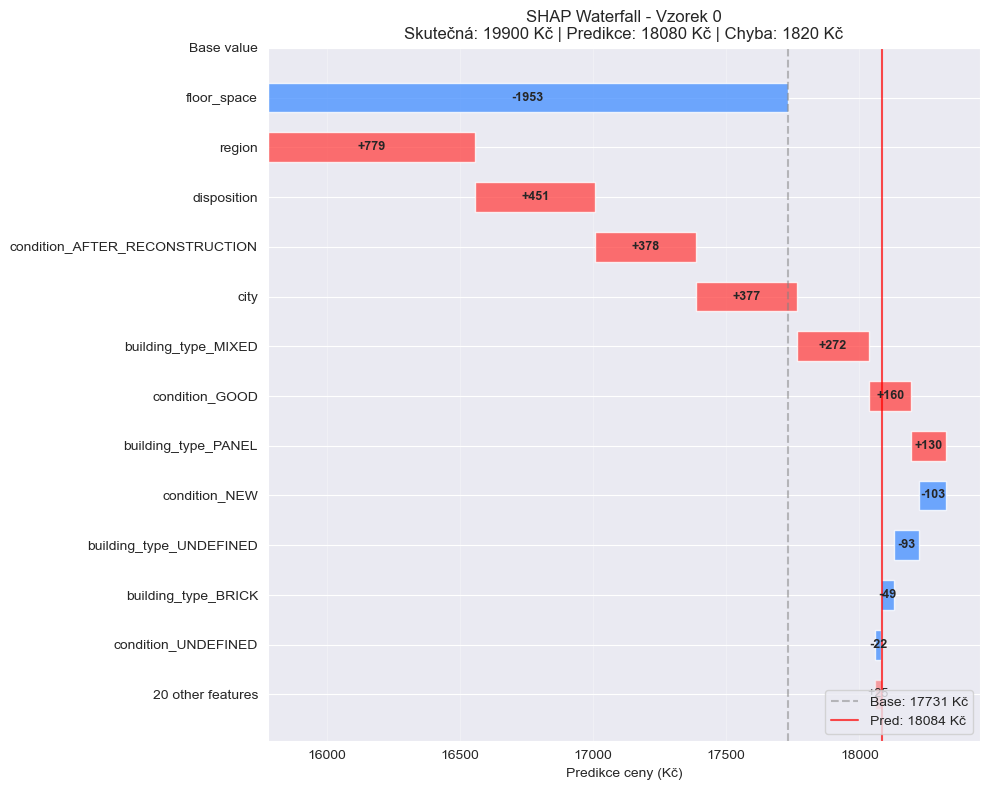

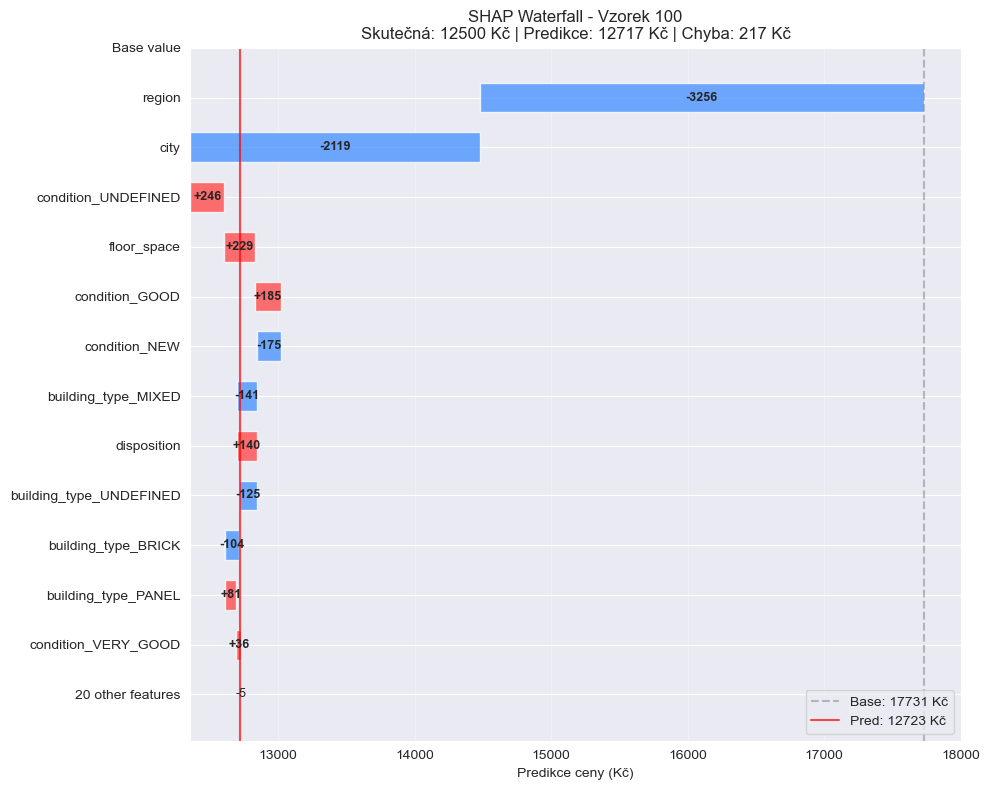

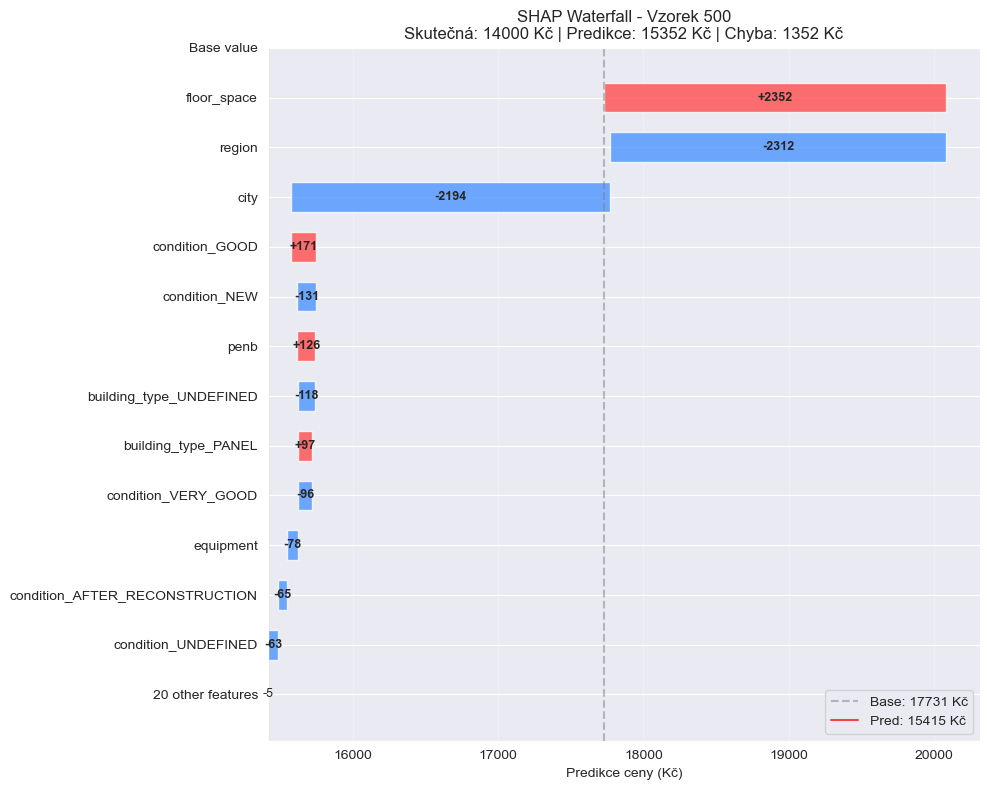

In [34]:
# SHAP Waterfall Plot
# Ukazuje jak každá feature přispěla k finální predikci

def plot_waterfall(sample_idx, shap_vals, base_val, feature_names, y_true, y_pred, max_display=12):
    """Vytvoří waterfall plot pro jednotlivou predikci."""
    
    # Seřazení podle absolutní hodnoty SHAP
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:max_display]
    sorted_shap = shap_vals[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    
    # Zbývající features
    remaining_idx = np.argsort(np.abs(shap_vals))[::-1][max_display:]
    remaining_sum = shap_vals[remaining_idx].sum()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Počáteční hodnota
    cumulative = base_val
    y_positions = list(range(len(sorted_shap) + 2))[::-1]  # +2 pro base a final
    
    # Barvy
    colors = ['#ff4d4d' if v > 0 else '#4d94ff' for v in sorted_shap]
    
    # Plot jednotlivých SHAP hodnot
    for i, (shap_val, name, color) in enumerate(zip(sorted_shap, sorted_names, colors)):
        left = min(cumulative, cumulative + shap_val)
        width = abs(shap_val)
        ax.barh(y_positions[i+1], width, left=left, color=color, alpha=0.8, height=0.6)
        
        # Anotace
        text_x = cumulative + shap_val/2
        sign = '+' if shap_val > 0 else ''
        ax.text(text_x, y_positions[i+1], f'{sign}{shap_val:.0f}', 
                ha='center', va='center', fontsize=9, fontweight='bold')
        
        cumulative += shap_val
    
    # Přidání zbývajících features
    if len(remaining_idx) > 0 and abs(remaining_sum) > 1:
        color = '#ff4d4d' if remaining_sum > 0 else '#4d94ff'
        left = min(cumulative, cumulative + remaining_sum)
        ax.barh(y_positions[-1], abs(remaining_sum), left=left, color=color, alpha=0.5, height=0.6)
        sign = '+' if remaining_sum > 0 else ''
        ax.text(cumulative + remaining_sum/2, y_positions[-1], f'{sign}{remaining_sum:.0f}', 
                ha='center', va='center', fontsize=9)
        cumulative += remaining_sum
    
    # Y-axis labels
    labels = ['Base value'] + sorted_names + [f'{len(remaining_idx)} other features']
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    
    # Vertikální čára pro base value a final
    ax.axvline(x=base_val, color='gray', linestyle='--', alpha=0.5, label=f'Base: {base_val:.0f} Kč')
    ax.axvline(x=cumulative, color='red', linestyle='-', alpha=0.7, label=f'Pred: {cumulative:.0f} Kč')
    
    ax.set_xlabel('Predikce ceny (Kč)')
    ax.set_title(f'SHAP Waterfall - Vzorek {sample_idx}\n'
                 f'Skutečná: {y_true:.0f} Kč | Predikce: {y_pred:.0f} Kč | Chyba: {abs(y_true-y_pred):.0f} Kč')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

# Vybereme zajímavé příklady
sample_indices = [0, 100, 500]

for idx in sample_indices:
    y_true = y_sample.iloc[idx]
    y_pred = best_model.predict(X_sample[idx:idx+1])[0]
    plot_waterfall(idx, shap_values[idx], base_value, all_feature_names, y_true, y_pred)

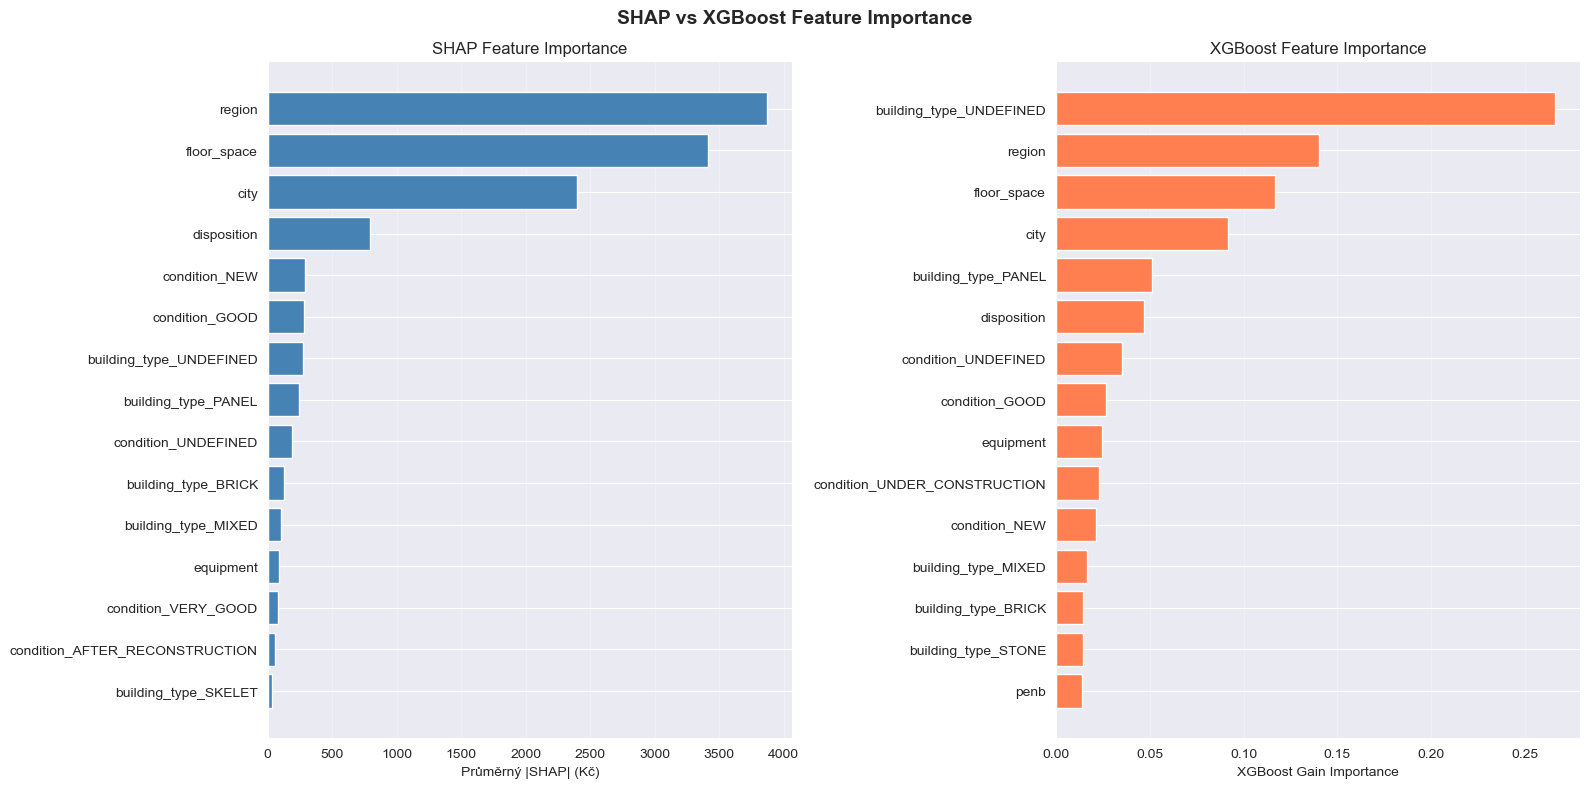


Spearman korelace mezi SHAP a XGBoost importance: 0.937 (p-value: 0.0000)


In [35]:
# Porovnání SHAP vs XGBoost Feature Importance
# SHAP ukazuje skutečný vliv na predikce, XGBoost importance ukazuje jak často se feature používá

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SHAP importance (
shap_imp_sorted = shap_importance_df.sort_values('mean_abs_shap', ascending=True).tail(15)
axes[0].barh(shap_imp_sorted['feature'], shap_imp_sorted['mean_abs_shap'], color='steelblue')
axes[0].set_xlabel('Průměrný |SHAP| (Kč)')
axes[0].set_title('SHAP Feature Importance')
axes[0].grid(True, alpha=0.3, axis='x')

# XGBoost Gain importance
xgb_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)
axes[1].barh(xgb_imp_df['feature'], xgb_imp_df['importance'], color='coral')
axes[1].set_xlabel('XGBoost Gain Importance')
axes[1].set_title('XGBoost Feature Importance')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('SHAP vs XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelace mezi metodami
from scipy.stats import spearmanr
corr, pval = spearmanr(mean_abs_shap, best_model.feature_importances_)
print(f'\nSpearman korelace mezi SHAP a XGBoost importance: {corr:.3f} (p-value: {pval:.4f})')

## 10. Uložení modelu

In [36]:
# Uložení nejlepšího modelu
best_model.save_model('../models/xgboost.json')
print('Model uložen do models/xgboost.json')

Model uložen do models/xgboost.json


## 11. Porovnání s RandomizedSearchCV

In [37]:
# Shrnutí výsledků
mae_random = mean_absolute_error(y_test, y_pred_random)
mae_optuna = mean_absolute_error(y_test, y_pred_test)
r2_random = r2_score(y_test, y_pred_random)
r2_optuna = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    'Metoda': ['RandomizedSearchCV', 'Optuna'],
    'MAE (Kč)': [mae_random, mae_optuna],
    'R²': [r2_random, r2_optuna]
})

print('=== POROVNÁNÍ METOD OPTIMALIZACE ===')
print(results.to_string(index=False))
print(f'\nLepší metoda: {"Optuna" if mae_optuna < mae_random else "RandomizedSearchCV"}')
print(f'Rozdíl v MAE: {abs(mae_random - mae_optuna):.2f} Kč')

=== POROVNÁNÍ METOD OPTIMALIZACE ===
            Metoda    MAE (Kč)       R²
RandomizedSearchCV 2755.024062 0.853369
            Optuna 2701.496997 0.850564

Lepší metoda: Optuna
Rozdíl v MAE: 53.53 Kč


## 12. Závěr

**Klíčové poznatky:**
- XGBoost nepotřebuje StandardScaler - stromové modely jsou invariantní vůči škálování
- Optuna (Bayesian optimization) typicky najde lepší hyperparametry než RandomizedSearchCV
- SHAP values pomocí **nativní XGBoost implementace** (`pred_contribs=True`):
  - Nevyžaduje externí knihovnu shap (žádné problémy s numba)
  - Poskytuje identické výsledky jako shap.TreeExplainer
  - Lokace (city, region) má největší vliv na cenu
  - Podlahová plocha je druhý nejdůležitější faktor
  - Můžeme vysvětlit jednotlivé predikce zákazníkům

**Pro produkční nasazení:**
- Použijte model uložený v `models/xgboost.json`
- Nezapomeňte aplikovat stejný preprocessing (bez scaleru)
- SHAP lze použít pro vysvětlení predikcí v aplikaci (nativní XGBoost metoda)
- Viz `huggingface_app/` pro příklad nasazení